In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/'
                 'machine-learning-databases'
                 '/breast-cancer-wisconsin/wdbc.data', header=None)


In [3]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
df.columns

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31],
      dtype='int64')

In [5]:
from sklearn.preprocessing import LabelEncoder

X= df.loc[:,2:].values
y= df.loc[:,1].values

le= LabelEncoder()
y= le.fit_transform(y)

print('Classes Representation: ', le.classes_)

Classes Representation:  ['B' 'M']


B is represented as 0 and M is represented as 1.

In [6]:
le.transform(['B', 'M'])

array([0, 1])

In [7]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test= train_test_split(
    X,
    y,
    test_size= 0.20,
    stratify= y,
    random_state= 42)

In [8]:
x_train.shape

(455, 30)

In [9]:
x_test.shape

(114, 30)

### Pipeline:

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline


In [11]:
lr_pipeline= make_pipeline(
    StandardScaler(),
    PCA(n_components= 2),
    LogisticRegression())

lr_pipeline.fit(x_train, y_train)
predictions= lr_pipeline.predict(x_test)
accuracy= lr_pipeline.score(x_test, y_test)
print('Accuracy of Logistic Regression: ', accuracy)

Accuracy of Logistic Regression:  0.9473684210526315


### Stratified K-Fold Cross Validation:

Following is the Stratified K fold functinality written without using sklearn k fold cross validation module that offers Stratified K fold cross validation:

In [12]:
import numpy as np
from sklearn.model_selection import StratifiedKFold

stratified_kfolds= StratifiedKFold(n_splits= 10).split(x_train, y_train)
kfolds_accuracy_scores= []

for k_fold, (train_folds, test_fold) in enumerate(stratified_kfolds):
    lr_pipeline.fit(x_train[train_folds], y_train[train_folds])
    fold_score= lr_pipeline.score(x_train[test_fold], y_train[test_fold])
    kfolds_accuracy_scores.append(fold_score)

    print(f'Fold: {k_fold+1:02d}, '
          f'Class distr.: {np.bincount(y_train[train_folds])}, '
          f'Acc.: {fold_score:.3f}')
    
mean_acc = np.mean(kfolds_accuracy_scores)
std_acc = np.std(kfolds_accuracy_scores)
print(f'\nCV accuracy: {mean_acc:.3f} +/- {std_acc:.3f}')

Fold: 01, Class distr.: [256 153], Acc.: 0.957
Fold: 02, Class distr.: [256 153], Acc.: 0.913
Fold: 03, Class distr.: [256 153], Acc.: 0.978
Fold: 04, Class distr.: [256 153], Acc.: 1.000
Fold: 05, Class distr.: [256 153], Acc.: 0.935
Fold: 06, Class distr.: [257 153], Acc.: 0.911
Fold: 07, Class distr.: [257 153], Acc.: 0.911
Fold: 08, Class distr.: [257 153], Acc.: 0.978
Fold: 09, Class distr.: [257 153], Acc.: 0.911
Fold: 10, Class distr.: [257 153], Acc.: 0.956

CV accuracy: 0.945 +/- 0.032


Here is how we can do it with the sklearn cross validation module:

In [13]:
from sklearn.model_selection import cross_val_score

scores= cross_val_score(estimator= lr_pipeline,
                                    X= x_train,
                                   y= y_train,
                                   cv= 10,
                                   n_jobs= -1 #advantage --> By n_jobs we can allow this module to use multiple CPUs available (by 1 it is using 1 CPU, by -1 it will use all the available CPUs)
                                  )

print(f'CV accuracy scores: {scores}')
print(f'CV accuracy: {np.mean(scores):.3f} '
      f'+/- {np.std(scores):.3f}')


CV accuracy scores: [0.95652174 0.91304348 0.97826087 1.         0.93478261 0.91111111
 0.91111111 0.97777778 0.91111111 0.95555556]
CV accuracy: 0.945 +/- 0.032


## Diagnosing our ML models:

To check how much they are generalizing by using overfitting and underfitting metrics.

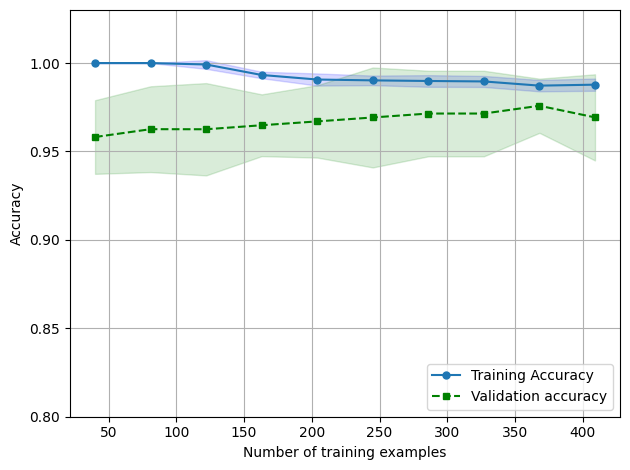

In [20]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

lr_pipeline= make_pipeline(StandardScaler(),
                           LogisticRegression(penalty= 'l2',
                                              max_iter= 10000)
                          )

train_sizes, train_scores, test_scores= learning_curve(estimator= lr_pipeline,
                                                       X= x_train,
                                                       y= y_train,
                                                       train_sizes= np.linspace(0.1, 1.0, 10),
                                                       cv= 10,
                                                       n_jobs= 1
                                                      )

training_mean= np.mean(train_scores, axis=1)
train_std= np.std(train_scores, axis= 1)
testing_mean= np.mean(test_scores, axis= 1)
test_std= np.std(test_scores, axis= 1)

plt.plot(train_sizes,
         training_mean,
         marker= 'o',
         markersize=5,
         label= 'Training Accuracy'
        )
plt.fill_between(train_sizes,
                 training_mean + train_std,
                 training_mean - train_std,
                 alpha=0.15, color='blue')

plt.plot(train_sizes, testing_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Validation accuracy')
plt.fill_between(train_sizes,
                 testing_mean + test_std,
                 testing_mean - test_std,
                 alpha=0.15, color='green')

plt.grid()
plt.xlabel('Number of training examples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim([0.8, 1.03])
plt.tight_layout()
plt.show()

**It fits very well after 250, byt after 400 it is kind of getting wider. That means overfitting is starting.**